In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [5]:
df = pd.read_csv("../data/Online_Retail.csv")
df.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2,2010-12-01 08:26:00,7.65,17850.0,United Kingdom
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6,2010-12-01 08:26:00,4.25,17850.0,United Kingdom
7,536366,22633,HAND WARMER UNION JACK,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
8,536366,22632,HAND WARMER RED POLKA DOT,6,2010-12-01 08:28:00,1.85,17850.0,United Kingdom
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom


In [6]:
print(df.shape)
df.columns.tolist()

(541909, 8)


['InvoiceNo',
 'StockCode',
 'Description',
 'Quantity',
 'InvoiceDate',
 'UnitPrice',
 'CustomerID',
 'Country']

In [7]:
df.info()
df.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,541909,541909,540455,541909.000000,541909,541909.000000,406829.000000,541909
unique,25900,4070,4223,NaN,23260,NaN,NaN,38
top,573585,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,2011-10-31 14:41:00,NaN,NaN,United Kingdom
freq,1114,2313,2369,NaN,1114,NaN,NaN,495478
mean,NaN,NaN,NaN,9.552250,NaN,4.611114,15287.690570,NaN
std,NaN,NaN,NaN,218.081158,NaN,96.759853,1713.600303,NaN
min,NaN,NaN,NaN,-80995.000000,NaN,-11062.060000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,NaN,1.250000,13953.000000,NaN
50%,NaN,NaN,NaN,3.000000,NaN,2.080000,15152.000000,NaN
75%,NaN,NaN,NaN,10.000000,NaN,4.130000,16791.000000,NaN


In [8]:
print("Unique invoices:", df["InvoiceNo"].nunique())
print("Unique products:", df["StockCode"].nunique())
print("Unique descriptions:", df["Description"].nunique())
print("Unique customers:", df["CustomerID"].nunique())
print("Unique countries:", df["Country"].nunique())

Unique invoices: 25900
Unique products: 4070
Unique descriptions: 4223
Unique customers: 4372
Unique countries: 38


In [9]:
print(df.isnull().sum())
print(df.duplicated().sum())


InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64
5268


# 3.Transaction & Data Quality Analysis

In [10]:
cancelled = df["InvoiceNo"].astype(str).str.startswith("C")

print("Cancelled rows:", cancelled.sum())
print("Normal rows:", (~cancelled).sum())
print("Cancellation percentage:", cancelled.mean() * 100)

Cancelled rows: 9288
Normal rows: 532621
Cancellation percentage: 1.7139409015166756


In [11]:
print("Cancelled invoices:", df.loc[cancelled, "InvoiceNo"].nunique())
df.loc[cancelled].head(10)

Cancelled invoices: 3836


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,2010-12-01 10:24:00,3.45,17548.0,United Kingdom
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
939,C536506,22960,JAM MAKING SET WITH JARS,-6,2010-12-01 12:38:00,4.25,17897.0,United Kingdom


In [12]:
negative_qty = df["Quantity"] < 0
print("Negative quantity rows:", negative_qty.sum())
print("Percentage:", negative_qty.mean() * 100)
df.loc[negative_qty].head(10)

Negative quantity rows: 10624
Percentage: 1.9604767590130447


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
238,C536391,21980,PACK OF 12 RED RETROSPOT TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
239,C536391,21484,CHICK GREY HOT WATER BOTTLE,-12,2010-12-01 10:24:00,3.45,17548.0,United Kingdom
240,C536391,22557,PLASTERS IN TIN VINTAGE PAISLEY,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
241,C536391,22553,PLASTERS IN TIN SKULLS,-24,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
939,C536506,22960,JAM MAKING SET WITH JARS,-6,2010-12-01 12:38:00,4.25,17897.0,United Kingdom


In [13]:
pd.crosstab(
    df["InvoiceNo"].astype(str).str.startswith("C"),
    df["Quantity"] < 0
)

Quantity,False,True
InvoiceNo,,
False,531285,1336
True,0,9288


In [14]:
zero_price = df["UnitPrice"] == 0
negative_price = df["UnitPrice"] < 0

print("Zero-price rows:", zero_price.sum())
print("Negative-price rows:", negative_price.sum())

df.loc[zero_price | negative_price].head(20)

Zero-price rows: 2515
Negative-price rows: 2


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
1988,536550,85044,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2024,536552,20950,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2025,536553,37461,NaN,3,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2026,536554,84670,NaN,23,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom


In [15]:
print(
    "Missing Description + negative quantity:",
    ((df["Description"].isna()) & (df["Quantity"] < 0)).sum()
)
df[df["Description"].isna()].head(20)

Missing Description + negative quantity: 862


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
622,536414,22139,NaN,56,2010-12-01 11:52:00,0.0,NaN,United Kingdom
1970,536545,21134,NaN,1,2010-12-01 14:32:00,0.0,NaN,United Kingdom
1971,536546,22145,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1972,536547,37509,NaN,1,2010-12-01 14:33:00,0.0,NaN,United Kingdom
1987,536549,85226A,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
1988,536550,85044,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2024,536552,20950,NaN,1,2010-12-01 14:34:00,0.0,NaN,United Kingdom
2025,536553,37461,NaN,3,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2026,536554,84670,NaN,23,2010-12-01 14:35:00,0.0,NaN,United Kingdom
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom


In [16]:
df[df.duplicated(keep=False)].sort_values(
    ["InvoiceNo", "StockCode"]
).head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
565,536412,21448,12 DAISY PEGS IN WOOD BOX,2,2010-12-01 11:49:00,1.65,17920.0,United Kingdom
578,536412,21448,12 DAISY PEGS IN WOOD BOX,1,2010-12-01 11:49:00,1.65,17920.0,United Kingdom


In [17]:
df[
    (df["Quantity"] < 0) &
    (~df["InvoiceNo"].astype(str).str.startswith("C"))
    ].head(20)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
2406,536589,21777,NaN,-10,2010-12-01 16:50:00,0.0,NaN,United Kingdom
4347,536764,84952C,NaN,-38,2010-12-02 14:42:00,0.0,NaN,United Kingdom
7188,536996,22712,NaN,-20,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7189,536997,22028,NaN,-20,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7190,536998,85067,NaN,-6,2010-12-03 15:30:00,0.0,NaN,United Kingdom
7192,537000,21414,NaN,-22,2010-12-03 15:32:00,0.0,NaN,United Kingdom
7193,537001,21653,NaN,-6,2010-12-03 15:33:00,0.0,NaN,United Kingdom
7195,537003,85126,NaN,-2,2010-12-03 15:33:00,0.0,NaN,United Kingdom
7196,537004,21814,NaN,-30,2010-12-03 15:34:00,0.0,NaN,United Kingdom
7197,537005,21692,NaN,-70,2010-12-03 15:35:00,0.0,NaN,United Kingdom


# 4. Data Cleaning

In [18]:
df_clean = df.copy()
report = {}
report["initial"] = len(df_clean)


### Remove non-product/service entries

In [19]:
service_codes = [
    "POST",
    "DOT",
    "M",
    "BANK CHARGES",
    "PADS"
]

df_product_clean = df_clean[
    ~df_clean["StockCode"].isin(service_codes)
].copy()

print("Original df_clean:", df_clean.shape)
print("Product-only df:", df_product_clean.shape)

df_clean = df_product_clean

Original df_clean: (541909, 8)
Product-only df: (539331, 8)


In [20]:
report["c_before"] = len(df_clean)
df_clean.drop(
    df_clean[df_clean["InvoiceNo"].astype(str).str.startswith("C")].index,
    axis=0,
    inplace=True,
)
report["c_after"] = len(df_clean)


In [21]:
report["q_before"] = len(df_clean)
df_clean.drop(
    df_clean[df_clean["Quantity"] < 0].index,
    axis=0,
    inplace=True
)
report["q_after"] = len(df_clean)


In [22]:
report["p_before"] = len(df_clean)
df_clean.drop(
    df_clean[df_clean["UnitPrice"] <= 0].index,
    axis=0,
    inplace=True
)
report["p_after"] = len(df_clean)


In [23]:
c_rem = report["c_before"] - report["c_after"]
q_rem = report["q_before"] - report["q_after"]
p_rem = report["p_before"] - report["p_after"]
t_rem = report["initial"] - report["p_after"]

print("=" * 65)
print(
    f"{'OPERATION':<25} | {'BEFORE':<8} | {'REMOVED':<7} | {'REMAINING':<9} | {'% REM'}"
)
print("=" * 65)
print(
    f"{'Cancellations':<25} | {report['c_before']:<8} | {c_rem:<7} | {report['c_after']:<9} | {(c_rem/report['c_before'])*100:.2f}%"
)
print(
    f"{'Negative Quantities':<25} | {report['q_before']:<8} | {q_rem:<7} | {report['q_after']:<9} | {(q_rem/report['q_before'])*100:.2f}%"
)
print(
    f"{'Zero/Negative Prices':<25} | {report['p_before']:<8} | {p_rem:<7} | {report['p_after']:<9} | {(p_rem/report['p_before'])*100:.2f}%"
)
print("=" * 65)
print(
    f"{'TOTAL DATASET CHANGE':<25} | {report['initial']:<8} | {t_rem:<7} | {report['p_after']:<9} | {(t_rem/report['initial'])*100:.2f}%"
)
print("=" * 65)


OPERATION                 | BEFORE   | REMOVED | REMAINING | % REM
Cancellations             | 539331   | 8892    | 530439    | 1.65%
Negative Quantities       | 530439   | 1336    | 529103    | 0.25%
Zero/Negative Prices      | 529103   | 1167    | 527936    | 0.22%
TOTAL DATASET CHANGE      | 541909   | 13973   | 527936    | 2.58%


In [24]:
missing_desc = df_clean[df_clean["Description"].isna()]

print("Rows with missing Description:", len(missing_desc))
print("Unique StockCodes:", missing_desc["StockCode"].nunique())

Rows with missing Description: 0
Unique StockCodes: 0


In [25]:
print(df_clean.shape)
print(df_clean.isnull().sum())
print("Cancelled invoices remaining:",
      df_clean["InvoiceNo"].astype(str).str.startswith("C").sum())

print("Negative quantities remaining:",
      (df_clean["Quantity"] < 0).sum())

print("Invalid prices remaining:",
      (df_clean["UnitPrice"] <= 0).sum())

print("Duplicate rows:",
      df_clean.duplicated().sum())

(527936, 8)
InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     131466
Country             0
dtype: int64
Cancelled invoices remaining: 0
Negative quantities remaining: 0
Invalid prices remaining: 0
Duplicate rows: 5221


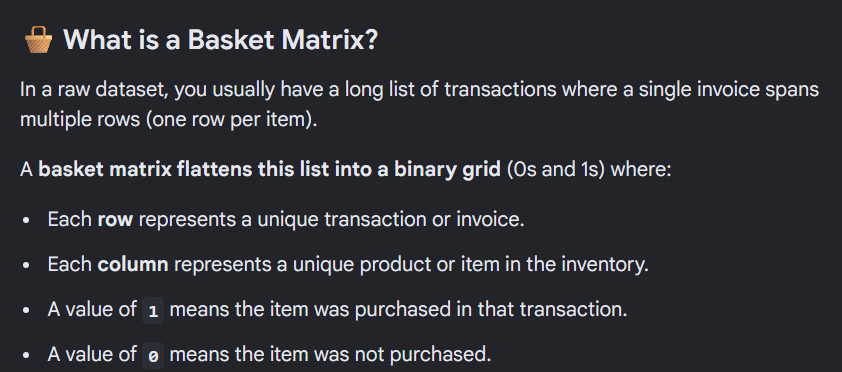

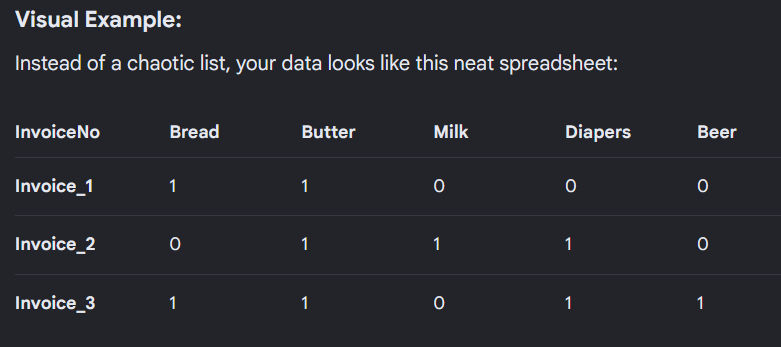


# 5. Final Basket Definition for the project

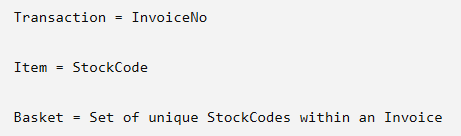
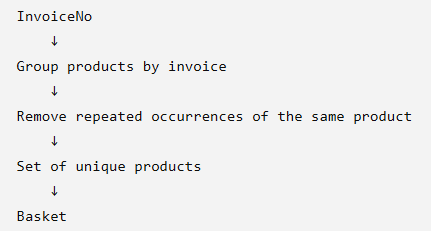

In [26]:
sample_invoices = df_clean["InvoiceNo"].drop_duplicates().head(5)

df_clean[
    df_clean["InvoiceNo"].isin(sample_invoices) # Row
    ][["InvoiceNo", "StockCode", "Description", "Quantity"]] # columns


,InvoiceNo,StockCode,Description,Quantity
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6
1,536365,71053,WHITE METAL LANTERN,6
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6
5,536365,22752,SET 7 BABUSHKA NESTING BOXES,2
6,536365,21730,GLASS STAR FROSTED T-LIGHT HOLDER,6
7,536366,22633,HAND WARMER UNION JACK,6
8,536366,22632,HAND WARMER RED POLKA DOT,6
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32



# 6. Basket Statistics

In [27]:
basket_sizes = df_clean.groupby("InvoiceNo")["StockCode"].nunique()

print("Number of baskets:", basket_sizes.shape[0])
print("Number of unique products:", df_clean["StockCode"].nunique())

print("\nBasket size statistics:")
print(basket_sizes.describe())


Number of baskets: 19781
Number of unique products: 3917

Basket size statistics:
count    19781.000000
mean        26.159800
std         47.021121
min          1.000000
25%          6.000000
50%         15.000000
75%         29.000000
max       1109.000000
Name: StockCode, dtype: float64


<Axes: xlabel='StockCode', ylabel='Count'>

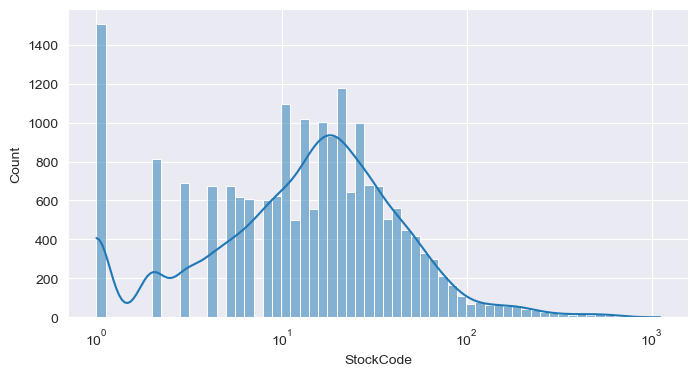

In [28]:
plt.figure(figsize=(8,4))
sns.histplot(basket_sizes , kde = True , log_scale=True)

# 6. Product Frequency Analysis

In [29]:
product_frequency = (
    df_clean.groupby("StockCode")["InvoiceNo"]
    .nunique()
    .sort_values(ascending=False)
)

print(product_frequency.head(20))

StockCode
85123A    2198
85099B    2089
22423     1988
47566     1685
20725     1565
84879     1455
22197     1392
22720     1385
21212     1320
22383     1284
20727     1273
22457     1249
23203     1231
22386     1218
22469     1201
21931     1184
22411     1175
22961     1162
22086     1160
22382     1157
Name: InvoiceNo, dtype: int64


In [30]:
print("Most frequent product:", product_frequency.index[0])
print("Maximum basket occurrence:", product_frequency.iloc[0])

print("\nProduct frequency statistics:")
print(product_frequency.describe())

Most frequent product: 85123A
Maximum basket occurrence: 2198

Product frequency statistics:
count    3917.000000
mean      132.107991
std       193.107327
min         1.000000
25%        16.000000
50%        65.000000
75%       164.000000
max      2198.000000
Name: InvoiceNo, dtype: float64


In [31]:
print("Products appearing in only 1 basket:",
      (product_frequency == 1).sum())

print("Products appearing in <= 5 baskets:",
      (product_frequency <= 5).sum())

print("Products appearing in <= 10 baskets:",
      (product_frequency <= 10).sum())

Products appearing in only 1 basket: 159
Products appearing in <= 5 baskets: 516
Products appearing in <= 10 baskets: 787



# 7. Product Filtering Analysis


In [32]:
thresholds = [1, 5, 10, 20, 50, 100]

for threshold in thresholds:
    count = (product_frequency >= threshold).sum()
    percentage = count / len(product_frequency) * 100

    print(
        f"Products appearing in >= {threshold:3} baskets: "
        f"{count:4} ({percentage:.2f}%)"
    )

Products appearing in >=   1 baskets: 3917 (100.00%)
Products appearing in >=   5 baskets: 3470 (88.59%)
Products appearing in >=  10 baskets: 3180 (81.18%)
Products appearing in >=  20 baskets: 2833 (72.33%)
Products appearing in >=  50 baskets: 2164 (55.25%)
Products appearing in >= 100 baskets: 1535 (39.19%)


In [33]:
filter_analysis = pd.DataFrame({
    "min_baskets": thresholds,
    "products_remaining": [
        (product_frequency >= t).sum()
        for t in thresholds
    ]
})

filter_analysis["percentage_remaining"] = (
        filter_analysis["products_remaining"]
        / len(product_frequency) * 100
)

print(filter_analysis)

   min_baskets  products_remaining  percentage_remaining
0            1                3917            100.000000
1            5                3470             88.588205
2           10                3180             81.184580
3           20                2833             72.325760
4           50                2164             55.246362
5          100                1535             39.188154


# 6 and 7 Product Frequency Analysis and Filtering

## Why did we do this step?

- Our cleaned dataset contains **3,922 unique products**.
- Before applying Apriori or FP-Growth, we need to understand how frequently each product appears across different baskets (invoices).
- A product's frequency tells us **how many different invoices/baskets contain that product**.
- We found that some products appear very frequently, while many products appear only a few times.
- For example:
  - 159 products appear in only 1 basket.
  - 517 products appear in 5 or fewer baskets.
  - 788 products appear in 10 or fewer baskets.
- These very rare products provide very little transaction history for discovering recurring associations.

## Why is product filtering important?

- Association Rule Mining searches for combinations of products.
- With thousands of products, the number of possible product combinations can become extremely large.
- Apriori can therefore become computationally expensive when the product space is large.
- Removing extremely rare products reduces the number of products that Apriori and FP-Growth need to consider.
- This can reduce computation and help focus the analysis on products that occur often enough to potentially form recurring patterns.

## What is the threshold?

- The threshold represents the **minimum number of different baskets/invoices in which a product must appear**.
- For example, a threshold of `10` means:
  - Keep a product if it appears in **10 or more different invoices**.
  - Remove a product if it appears in fewer than 10 invoices.
- This is based on `InvoiceNo`, not `CustomerID`.
- Therefore, 10 does **not** mean 10 different customers.

## Why did we test multiple thresholds?

We tested:

- 1 basket → 3,922 products remain
- 5 baskets → 3,474 products remain
- 10 baskets → 3,184 products remain
- 20 baskets → 2,836 products remain
- 50 baskets → 2,167 products remain
- 100 baskets → 1,538 products remain

This allows us to see how increasing the minimum occurrence requirement reduces the product search space.

## Why did we choose 10 as the initial threshold?

- At a threshold of 10, **3,184 out of 3,922 products remain**.
- This removes the very rare products while retaining about **81% of the products**.
- A higher threshold such as 100 would remove much more of the product space.
- Therefore, 10 provides a reasonable starting point for experimentation rather than aggressively removing products.

## Important distinction

The product-occurrence threshold is **not the same as minimum support**.

- **Product occurrence threshold:**
  Determines which individual products are retained before mining.

- **Minimum support:**
  Determines which itemsets are considered frequent during Apriori or FP-Growth.

For example, with 19,960 baskets:

- Product occurrence threshold = `10`
  → product must occur in at least 10 invoices.

- Minimum support = `0.01`
  → an itemset must occur in at least 1% of baskets.

## Overall purpose

The purpose of this step is:

**Understand product frequency → investigate rare products → measure the effect of filtering → choose a justified initial filtering threshold → prepare the data for efficient association-rule mining.**


# 8. Apply Product Filtering

In [34]:
min_product_occurrence = 10

frequent_products = product_frequency[
    product_frequency >= min_product_occurrence
    ].index

df_filtered = df_clean[
    df_clean["StockCode"].isin(frequent_products)
].copy()

In [35]:
print("Rows before filtering:", len(df_clean))
print("Rows after filtering:", len(df_filtered))

print("\nProducts before filtering:", df_clean["StockCode"].nunique())
print("Products after filtering:", df_filtered["StockCode"].nunique())

print("\nRows removed:", len(df_clean) - len(df_filtered))

Rows before filtering: 527936
Rows after filtering: 524916

Products before filtering: 3917
Products after filtering: 3180

Rows removed: 3020


In [36]:
print("\nBaskets before filtering:", df_clean["InvoiceNo"].nunique())
print("Baskets after filtering:", df_filtered["InvoiceNo"].nunique())


Baskets before filtering: 19781
Baskets after filtering: 19748


In [37]:
filtered_basket_sizes = (
    df_filtered.groupby("InvoiceNo")["StockCode"]
    .nunique()
)

print("\nFiltered basket size statistics:")
print(filtered_basket_sizes.describe())


Filtered basket size statistics:
count    19748.000000
mean        26.053119
std         46.629372
min          1.000000
25%          6.000000
50%         15.000000
75%         29.000000
max       1081.000000
Name: StockCode, dtype: float64



# 9. Build the Basket

In [38]:
basket_data = df_filtered[
    ["InvoiceNo", "StockCode"]
].drop_duplicates()

print("Rows after removing repeated invoice-product pairs:",
      len(basket_data))

print("Unique invoices:", basket_data["InvoiceNo"].nunique())
print("Unique products:", basket_data["StockCode"].nunique())

Rows after removing repeated invoice-product pairs: 514497
Unique invoices: 19748
Unique products: 3180


In [39]:
basket_sample = (
    basket_data
    .groupby("InvoiceNo")["StockCode"]
    .apply(list)
)

print(basket_sample.head())

InvoiceNo
536365    [85123A, 71053, 84406B, 84029G, 84029E, 22752,...
536366                                       [22633, 22632]
536367    [84879, 22745, 22748, 22749, 22310, 84969, 226...
536368                         [22960, 22913, 22912, 22914]
536369                                              [21756]
Name: StockCode, dtype: object



# 10. Create Transaction × Product Matrix

In [40]:
basket_matrix = pd.crosstab(
    basket_data["InvoiceNo"],
    basket_data["StockCode"]
).astype(bool)

print("Matrix shape:", basket_matrix.shape)
print("Memory usage:",
      basket_matrix.memory_usage(deep=True).sum() / 1024**2,
      "MB")

Matrix shape: (19748, 3180)
Memory usage: 60.92527389526367 MB


In [41]:
print(basket_matrix.head())

StockCode  10002  10080  10120  10125  10133  10135  11001  15030  15034  \
InvoiceNo                                                                  
536365     False  False  False  False  False  False  False  False  False   
536366     False  False  False  False  False  False  False  False  False   
536367     False  False  False  False  False  False  False  False  False   
536368     False  False  False  False  False  False  False  False  False   
536369     False  False  False  False  False  False  False  False  False   

StockCode  15036  ...  90214N  90214P  90214R  90214S  90214T  90214V  90214Z  \
InvoiceNo         ...                                                           
536365     False  ...   False   False   False   False   False   False   False   
536366     False  ...   False   False   False   False   False   False   False   
536367     False  ...   False   False   False   False   False   False   False   
536368     False  ...   False   False   False   False   False 

In [42]:
# Example Check

invoice = basket_matrix.loc["536365"]

print(invoice[invoice])
print("Products in invoice 536365:", invoice.sum())

StockCode
21730     True
22752     True
71053     True
84029E    True
84029G    True
84406B    True
85123A    True
Name: 536365, dtype: bool
Products in invoice 536365: 7



# 11. Verify the Basket Matrix

In [43]:
print("Matrix shape:", basket_matrix.shape)

print("Total baskets:", basket_matrix.shape[0])
print("Total products:", basket_matrix.shape[1])

print("Total True values:", basket_matrix.values.sum())

Matrix shape: (19748, 3180)
Total baskets: 19748
Total products: 3180
Total True values: 514497


In [44]:
print("Average products per basket:",
      basket_matrix.sum(axis=1).mean())

print("Minimum products in a basket:",
      basket_matrix.sum(axis=1).min())

print("Maximum products in a basket:",
      basket_matrix.sum(axis=1).max())

Average products per basket: 26.05311930322058
Minimum products in a basket: 1
Maximum products in a basket: 1081



# 12. Product Frequency in the Basket Matrix

In [45]:
matrix_product_frequency = basket_matrix.sum(axis=0).sort_values(ascending=False)

print(matrix_product_frequency.head(20))

StockCode
85123A    2198
85099B    2089
22423     1988
47566     1685
20725     1565
84879     1455
22197     1392
22720     1385
21212     1320
22383     1284
20727     1273
22457     1249
23203     1231
22386     1218
22469     1201
21931     1184
22411     1175
22961     1162
22086     1160
22382     1157
dtype: int64


In [46]:
matrix_product_support = (
        matrix_product_frequency / len(basket_matrix)
)

print(matrix_product_support.head(20))

StockCode
85123A    0.111302
85099B    0.105783
22423     0.100668
47566     0.085325
20725     0.079249
84879     0.073678
22197     0.070488
22720     0.070134
21212     0.066842
22383     0.065019
20727     0.064462
22457     0.063247
23203     0.062335
22386     0.061677
22469     0.060816
21931     0.059955
22411     0.059500
22961     0.058841
22086     0.058740
22382     0.058588
dtype: float64



# 13. Frequent Itemsets & Apriori Theory

# Step 14 — Frequent Itemsets and Apriori

## What is an Itemset?

- An itemset is a collection of one or more products.
- A single product is a 1-itemset.
- Two products together form a 2-itemset.
- Three products together form a 3-itemset.

Examples:

- {85123A}
- {85123A, 85099B}
- {85123A, 85099B, 22423}

## What is a Frequent Itemset?

- A frequent itemset is an itemset that appears in enough baskets to satisfy the chosen minimum support.
- For example, if the minimum support is 1%, an itemset must appear in at least 1% of all baskets.
- Frequent itemsets are the foundation for generating association rules.

## What is Apriori?

- Apriori is an algorithm used to find frequent itemsets.
- It starts by finding frequent individual products.
- It then generates larger candidate itemsets from frequent smaller itemsets.
- Itemsets that do not satisfy minimum support are removed.
- The process continues for larger itemsets until no more frequent itemsets can be found.

## Apriori Principle

- Apriori uses the downward-closure property.
- If an itemset is not frequent, any larger itemset containing it cannot be frequent.
- Therefore, Apriori can prune many unnecessary candidate combinations.
- This pruning reduces the search space compared with checking every possible combination.

## Example

Suppose:

- {A, B} is not frequent.

Then:

- {A, B, C} cannot be frequent.
- {A, B, D} cannot be frequent.
- {A, B, C, D} cannot be frequent.

There is no need to calculate their support.

## Why is Apriori computationally expensive?

- The number of possible product combinations grows rapidly as the number of products increases.
- A low minimum support allows more itemsets to survive.
- More surviving itemsets create more candidates for the next level.
- Therefore, minimum support has a major effect on runtime and memory usage.

## What will we do next?

- Run Apriori with a controlled minimum support.
- Measure the number of frequent itemsets generated.
- Measure execution time.
- Experiment with different minimum-support values.
- Use these experiments to understand the trade-off between computational cost and the number of discovered patterns.


# 15. First Apriori Experiment

In [47]:
from mlxtend.frequent_patterns import apriori
import time

In [48]:
# support_values = [0.05, 0.03, 0.02, 0.01]
#
# apriori_results = {}
#
# for min_support in support_values:
#
#     start_time = time.time()
#
#     frequent_itemsets = apriori(
#         basket_matrix,
#         min_support=min_support,
#         use_colnames=True
#     )
#
#     end_time = time.time()
#
#     apriori_results[min_support] = frequent_itemsets
#
#     print("Minimum support:", min_support)
#     print("Frequent itemsets:", len(frequent_itemsets))
#     print("Execution time:", round(end_time - start_time, 2), "seconds")
#     print(50 * "=")

In [49]:
# import pickle
#
# with open("../results/frequent_itemsets/apriori_results.pkl", "wb") as f:
#     pickle.dump(apriori_results, f)
#
# print("Saved successfully.")

In [50]:
import pickle

with open("../results/frequent_itemsets/apriori_results.pkl", "rb") as f:
    apriori_results = pickle.load(f)

print("Loaded successfully.")

Loaded successfully.



# 16. Analyze Frequent Itemset Sizes

In [51]:
frequent_itemsets_01 = apriori_results[0.01]
itemset_sizes = frequent_itemsets_01["itemsets"].apply(len) # it counts each itemset len
print(itemset_sizes.value_counts().sort_index()) # then this  count per lenght ,  number of itemset

itemsets
1    829
2    894
3    258
4     25
5      1
Name: count, dtype: int64



# 17. Inspect the Frequent Itemsets

In [52]:
frequent_itemsets_01.sort_values(
    "support",
    ascending=False
).head(20)

,support,itemsets
822,0.111302,(85123A)
819,0.105783,(85099B)
329,0.100668,(22423)
734,0.085325,(47566)
22,0.079249,(20725)
793,0.073678,(84879)
276,0.070488,(22197)
450,0.070134,(22720)
81,0.066842,(21212)
317,0.065019,(22383)


In [53]:
# Specifically look at 2-itemsets

pairs = frequent_itemsets_01[
    frequent_itemsets_01["itemsets"].apply(len) == 2
    ]

pairs.sort_values(
    "support",
    ascending=False
).head(20)

# 1398, 1506, etc is the index

,support,itemsets
1402,0.041776,"(85099B, 22386)"
1505,0.038839,"(22699, 22697)"
1217,0.036662,"(21931, 85099B)"
1412,0.034434,"(22411, 85099B)"
959,0.033168,"(22383, 20725)"
943,0.032459,"(20727, 20725)"
1544,0.032408,"(22726, 22727)"
1504,0.032003,"(22698, 22697)"
960,0.030687,"(22384, 20725)"
1515,0.030282,"(22698, 22699)"



# 18. Largest Itemsets

In [54]:
largest_itemsets = frequent_itemsets_01[
    frequent_itemsets_01["itemsets"].apply(len) >= 3
    ].sort_values(
    "support",
    ascending=False
)

largest_itemsets.head(20)

,support,itemsets
1943,0.027395,"(22698, 22699, 22697)"
1905,0.020914,"(21931, 85099B, 22386)"
1939,0.020660,"(22699, 22423, 22697)"
1908,0.019749,"(21931, 22411, 85099B)"
1928,0.019141,"(22411, 85099B, 22386)"
1804,0.018280,"(20727, 22384, 20725)"
1803,0.018128,"(20727, 22383, 20725)"
1938,0.017369,"(22698, 22423, 22697)"
1743,0.017268,"(22386, 85099B, 20712)"
1809,0.017166,"(22383, 20728, 20725)"


In [55]:
largest_itemsets = frequent_itemsets_01[
    frequent_itemsets_01["itemsets"].apply(len) >= 3
    ].copy()

largest_itemsets["itemset_size"] = (
    largest_itemsets["itemsets"].apply(len)
)

largest_itemsets.sort_values(
    ["itemset_size", "support"],
    ascending=[False, False]
).head(20)

,support,itemsets,itemset_size
2006,0.010330,"(20719, 20724, 22356, 22355, 20723)",5
2005,0.015242,"(22698, 22699, 22423, 22697)",4
2001,0.013571,"(21931, 22411, 85099B, 22386)",4
1984,0.013166,"(20719, 20724, 22355, 20723)",4
1987,0.012710,"(20719, 20724, 22356, 22355)",4
1988,0.012406,"(22356, 20724, 22355, 20723)",4
1985,0.012254,"(20719, 20724, 22356, 20723)",4
1981,0.011849,"(21931, 22386, 85099B, 20712)",4
1990,0.011647,"(20727, 22383, 20728, 20725)",4
1991,0.011394,"(22384, 20728, 20727, 20725)",4



# 19. Generate Association Rules

In [56]:
from mlxtend.frequent_patterns import association_rules

rules_01 = association_rules(
    frequent_itemsets_01,
    metric="confidence",
    min_threshold=0.1
)

print("Number of rules:", len(rules_01))

rules_01.head(10)

Number of rules: 3670


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(20675),(20677),0.016305,0.016862,0.010533,0.645963,38.307724,1.0,0.010258,2.776932,0.990039,0.465324,0.639890,0.635294
1,(20677),(20675),0.016862,0.016305,0.010533,0.624625,38.307724,1.0,0.010258,2.620562,0.990600,0.465324,0.618403,0.635294
2,(20685),(85099B),0.035244,0.105783,0.010482,0.297414,2.811550,1.0,0.006754,1.272751,0.667862,0.080295,0.214300,0.198252
3,(20711),(20712),0.026433,0.043701,0.014634,0.553640,12.668922,1.0,0.013479,2.142439,0.946074,0.263686,0.533242,0.444259
4,(20712),(20711),0.043701,0.026433,0.014634,0.334878,12.668922,1.0,0.013479,1.463743,0.963157,0.263686,0.316820,0.444259
5,(21928),(20711),0.040814,0.026433,0.010077,0.246898,9.340511,1.0,0.008998,1.292743,0.930935,0.176262,0.226451,0.314062
6,(20711),(21928),0.026433,0.040814,0.010077,0.381226,9.340511,1.0,0.008998,1.550139,0.917183,0.176262,0.354897,0.314062
7,(21931),(20711),0.059955,0.026433,0.015090,0.251689,9.521759,1.0,0.013505,1.301019,0.952058,0.211648,0.231372,0.411285
8,(20711),(21931),0.026433,0.059955,0.015090,0.570881,9.521759,1.0,0.013505,2.190640,0.919277,0.211648,0.543512,0.411285
9,(20711),(22386),0.026433,0.061677,0.014280,0.540230,8.758998,1.0,0.012650,2.040852,0.909883,0.193416,0.510009,0.385878


In [57]:
# with open(
#         "../results/association_rules/rules_apriori.pkl",
#         "wb"
# ) as f:
#     pickle.dump(rules_01, f)
#
# print("Apriori rules saved.")


# 20. Inspect Rules by Confidence

In [58]:
rules_by_confidence = rules_01.sort_values(
    "confidence",
    ascending=False
)

rules_by_confidence[
    ["antecedents", "consequents", "support", "confidence", "lift"]
].head(20)

,antecedents,consequents,support,confidence,lift
3160,"(22916, 22918)",(22917),0.010280,0.953052,78.420266
3166,"(22916, 22920)",(22917),0.010128,0.952381,78.365079
3173,"(23170, 23172)",(23171),0.012913,0.947955,49.134444
3162,"(22918, 22917)",(22916),0.010280,0.944186,78.674203
3167,"(22917, 22920)",(22916),0.010128,0.934579,77.873733
1465,(22916),(22917),0.011191,0.932489,76.728340
3060,"(22579, 22577)",(22578),0.011697,0.927711,35.782097
1466,(22917),(22916),0.011191,0.920833,76.728340
3352,"(20719, 22356, 20723)",(20724),0.012254,0.920152,17.607717
3643,"(20719, 22356, 22355, 20723)",(20724),0.010330,0.918919,17.584119



# 21. Sort Rules by Lift

In [59]:
rules_by_lift = rules_01.sort_values(
    "lift",
    ascending=False
)

rules_by_lift[
    ["antecedents", "consequents", "support", "confidence", "lift"]
].head(20)

,antecedents,consequents,support,confidence,lift
3163,(22916),"(22918, 22917)",0.010280,0.856540,78.674203
3162,"(22918, 22917)",(22916),0.010280,0.944186,78.674203
3160,"(22916, 22918)",(22917),0.010280,0.953052,78.420266
3165,(22917),"(22916, 22918)",0.010280,0.845833,78.420266
3171,(22917),"(22916, 22920)",0.010128,0.833333,78.365079
3166,"(22916, 22920)",(22917),0.010128,0.952381,78.365079
3170,(22916),"(22917, 22920)",0.010128,0.843882,77.873733
3167,"(22917, 22920)",(22916),0.010128,0.934579,77.873733
1466,(22917),(22916),0.011191,0.920833,76.728340
1465,(22916),(22917),0.011191,0.932489,76.728340



# 22. Compare Support, Confidence and Lift

In [60]:
rules_01[
    ["antecedents", "consequents", "support", "confidence", "lift"]
].describe()



,support,confidence,lift
count,3670.000000,3670.000000,3670.000000
mean,0.013098,0.372491,10.371507
std,0.003714,0.194837,9.069341
min,0.010026,0.100048,1.355230
25%,0.010685,0.212397,5.338613
50%,0.011849,0.317179,8.602348
75%,0.014128,0.510664,12.242448
max,0.041776,0.953052,78.674203


In [61]:
print("Total rules:", len(rules_01))

print("Confidence >= 0.5:",
      (rules_01["confidence"] >= 0.5).sum())

print("Confidence >= 0.7:",
      (rules_01["confidence"] >= 0.7).sum())

print("Lift >= 2:",
      (rules_01["lift"] >= 2).sum())

print("Lift >= 5:",
      (rules_01["lift"] >= 5).sum())

print("Lift >= 10:",
      (rules_01["lift"] >= 10).sum())

Total rules: 3670
Confidence >= 0.5: 956
Confidence >= 0.7: 287
Lift >= 2: 3602
Lift >= 5: 2842
Lift >= 10: 1346


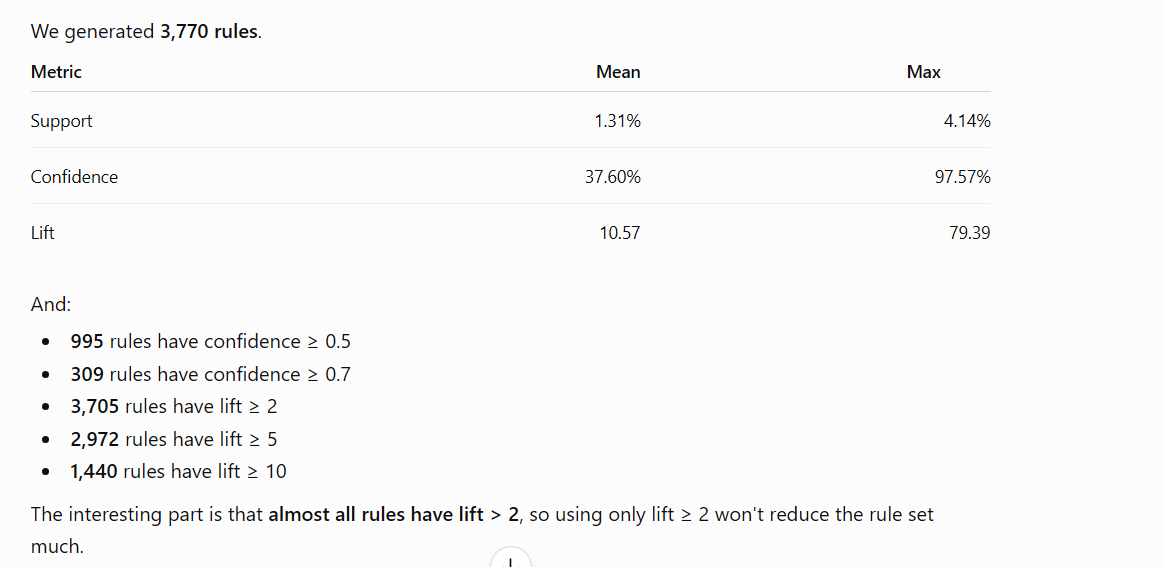

In [62]:
filtered_rules = rules_01[
    (rules_01["support"] >= 0.01) &
    (rules_01["confidence"] >= 0.5) &
    (rules_01["lift"] >= 2)
    ].copy()

print("Original rules:", len(rules_01))
print("Filtered rules:", len(filtered_rules))

Original rules: 3670
Filtered rules: 956


In [63]:
filtered_rules[
    ["antecedents", "consequents", "support", "confidence", "lift"]
].sort_values(
    ["lift", "confidence"],
    ascending=False
).head(20)

,antecedents,consequents,support,confidence,lift
3162,"(22918, 22917)",(22916),0.010280,0.944186,78.674203
3163,(22916),"(22918, 22917)",0.010280,0.856540,78.674203
3160,"(22916, 22918)",(22917),0.010280,0.953052,78.420266
3165,(22917),"(22916, 22918)",0.010280,0.845833,78.420266
3171,(22917),"(22916, 22920)",0.010128,0.833333,78.365079
3166,"(22916, 22920)",(22917),0.010128,0.952381,78.365079
3167,"(22917, 22920)",(22916),0.010128,0.934579,77.873733
3170,(22916),"(22917, 22920)",0.010128,0.843882,77.873733
1465,(22916),(22917),0.011191,0.932489,76.728340
1466,(22917),(22916),0.011191,0.920833,76.728340



# 24. Check Redundant / Similar Rules

In [64]:
filtered_rules["antecedent_size"] = (
    filtered_rules["antecedents"].apply(len)
)

filtered_rules["consequent_size"] = (
    filtered_rules["consequents"].apply(len)
)

filtered_rules[
    ["antecedent_size", "consequent_size"]
].value_counts().sort_index()

antecedent_size  consequent_size
1                1                  251
                 2                   22
2                1                  528
                 2                   39
                 3                    3
3                1                   98
                 2                   10
4                1                    5
Name: count, dtype: int64

In [65]:
filtered_rules[
    [
        "antecedents",
        "consequents",
        "antecedent_size",
        "consequent_size",
        "support",
        "confidence",
        "lift"
    ]
].sort_values(
    ["lift", "confidence"],
    ascending=False
).head(20)

,antecedents,consequents,antecedent_size,consequent_size,support,confidence,lift
3162,"(22918, 22917)",(22916),2,1,0.010280,0.944186,78.674203
3163,(22916),"(22918, 22917)",1,2,0.010280,0.856540,78.674203
3160,"(22916, 22918)",(22917),2,1,0.010280,0.953052,78.420266
3165,(22917),"(22916, 22918)",1,2,0.010280,0.845833,78.420266
3171,(22917),"(22916, 22920)",1,2,0.010128,0.833333,78.365079
3166,"(22916, 22920)",(22917),2,1,0.010128,0.952381,78.365079
3167,"(22917, 22920)",(22916),2,1,0.010128,0.934579,77.873733
3170,(22916),"(22917, 22920)",1,2,0.010128,0.843882,77.873733
1465,(22916),(22917),1,1,0.011191,0.932489,76.728340
1466,(22917),(22916),1,1,0.011191,0.920833,76.728340



# 25. Count Rule Structures

In [66]:
rule_structure_counts = (
    filtered_rules
    .groupby(["antecedent_size", "consequent_size"])
    .size()
    .reset_index(name="rule_count")
)

rule_structure_counts

,antecedent_size,consequent_size,rule_count
0,1,1,251
1,1,2,22
2,2,1,528
3,2,2,39
4,2,3,3
5,3,1,98
6,3,2,10
7,4,1,5



# 26. Select Representative Final Rules

In [67]:
final_candidate_rules = filtered_rules[
    [
        "antecedents",
        "consequents",
        "support",
        "confidence",
        "lift"
    ]
].sort_values(
    ["lift", "confidence", "support"],
    ascending=False
)

final_candidate_rules.head(30)

,antecedents,consequents,support,confidence,lift
3162,"(22918, 22917)",(22916),0.010280,0.944186,78.674203
3163,(22916),"(22918, 22917)",0.010280,0.856540,78.674203
3160,"(22916, 22918)",(22917),0.010280,0.953052,78.420266
3165,(22917),"(22916, 22918)",0.010280,0.845833,78.420266
3171,(22917),"(22916, 22920)",0.010128,0.833333,78.365079
3166,"(22916, 22920)",(22917),0.010128,0.952381,78.365079
3167,"(22917, 22920)",(22916),0.010128,0.934579,77.873733
3170,(22916),"(22917, 22920)",0.010128,0.843882,77.873733
1465,(22916),(22917),0.011191,0.932489,76.728340
1466,(22917),(22916),0.011191,0.920833,76.728340


# 27. Rule Visualization and Interpretation

Support measures how frequently a rule occurs in the transaction database, while confidence measures how often the consequent occurs when the antecedent is present.

Plotting these two metrics helps identify rules that are both sufficiently frequent and reliable.

### **Sampling Association Rules for Visualization**

In [68]:
import matplotlib.pyplot as plt

In [69]:
rules_sample = rules_01.sample(
    frac=0.20,
    random_state=42
)


print("Original rules:", len(rules_01))
print("Sampled rules:", len(rules_sample))

Original rules: 3670
Sampled rules: 734


## 27.1 Support vs Confidence

Support represents the proportion of baskets containing the rule, while confidence represents the conditional probability of the consequent given the antecedent.

The sampled scatter plot provides a clearer view of the overall relationship between these two metrics.

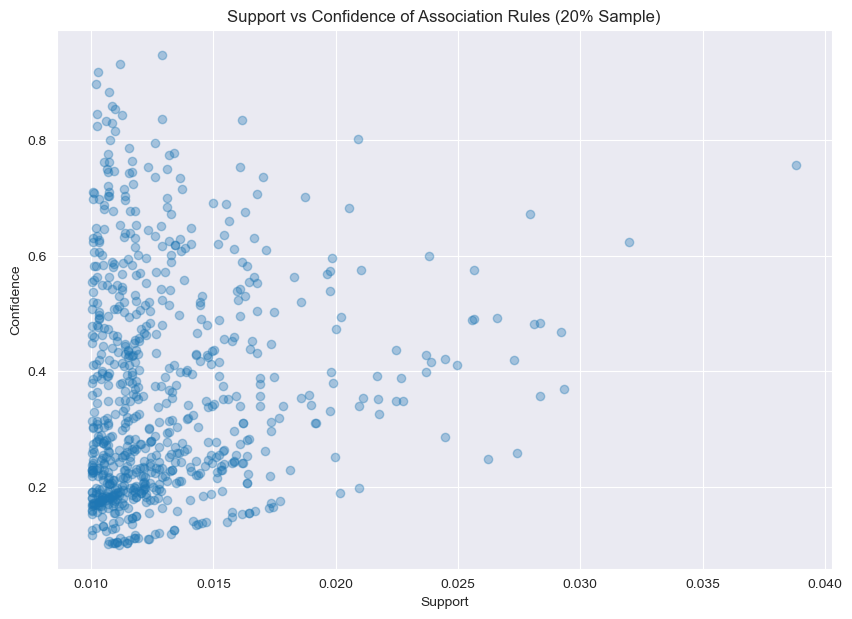

In [70]:
plt.figure(figsize=(10, 7))

plt.scatter(
    rules_sample["support"],
    rules_sample["confidence"],
    alpha=0.35
)


plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Support vs Confidence of Association Rules (20% Sample)")
plt.grid(True)

plt.show()

## 27.3 Support vs Lift

Lift measures the strength of association between the antecedent and consequent relative to their expected occurrence under independence.

The sampled scatter plot is used to visualize the relationship between rule support and lift while reducing visual overlap.

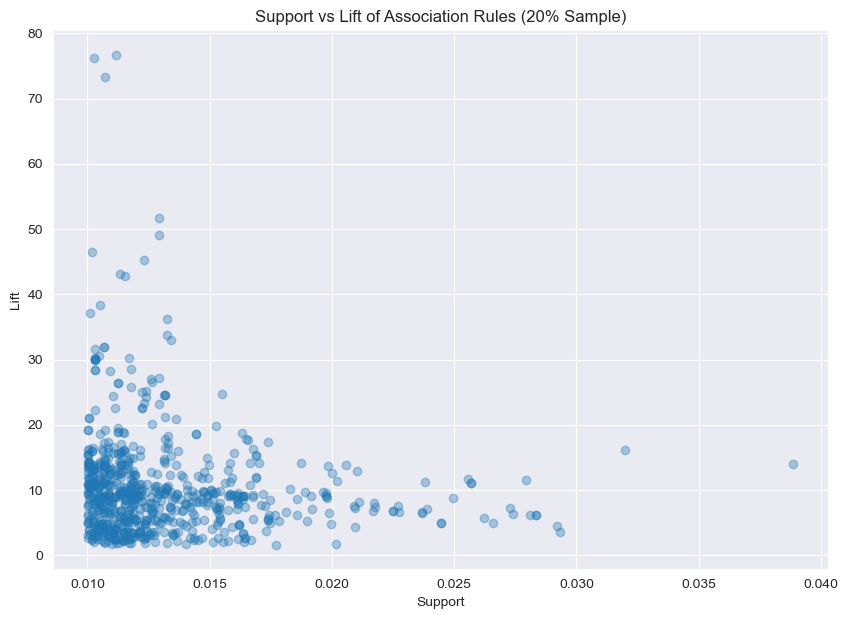

In [71]:
plt.figure(figsize=(10, 7))

plt.scatter(
    rules_sample["support"],
    rules_sample["lift"],
    alpha=0.35
)

plt.xlabel("Support")
plt.ylabel("Lift")
plt.title("Support vs Lift of Association Rules (20% Sample)")
plt.grid(True)

plt.show()

## 27.4 Confidence vs Lift

Confidence and lift provide different information about an association rule.

Confidence measures the conditional occurrence of the consequent, while lift compares the observed association with the expected association under independence.

The sampled scatter plot provides an overview of the relationship between these two metrics.

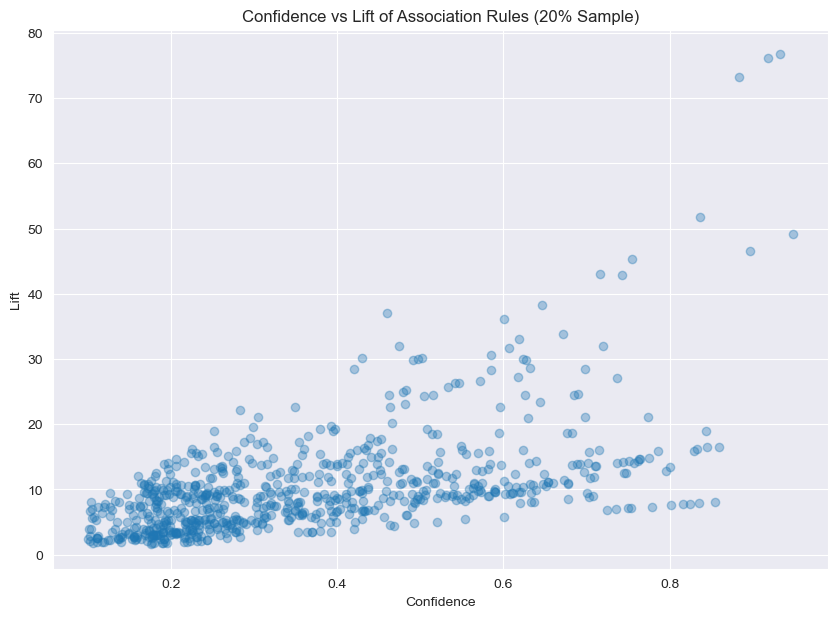

In [72]:
plt.figure(figsize=(10, 7))

plt.scatter(
    rules_sample["confidence"],
    rules_sample["lift"],
    alpha=0.35
)

plt.xlabel("Confidence")
plt.ylabel("Lift")
plt.title("Confidence vs Lift of Association Rules (20% Sample)")
plt.grid(True)

plt.show()

## 27.5 Filtered Rules: Support vs Confidence

The filtered rule set contains rules satisfying the selected support, confidence, and lift thresholds.

A 20% sample is used for visualization to reduce overlap while preserving the complete filtered rule set for analysis.

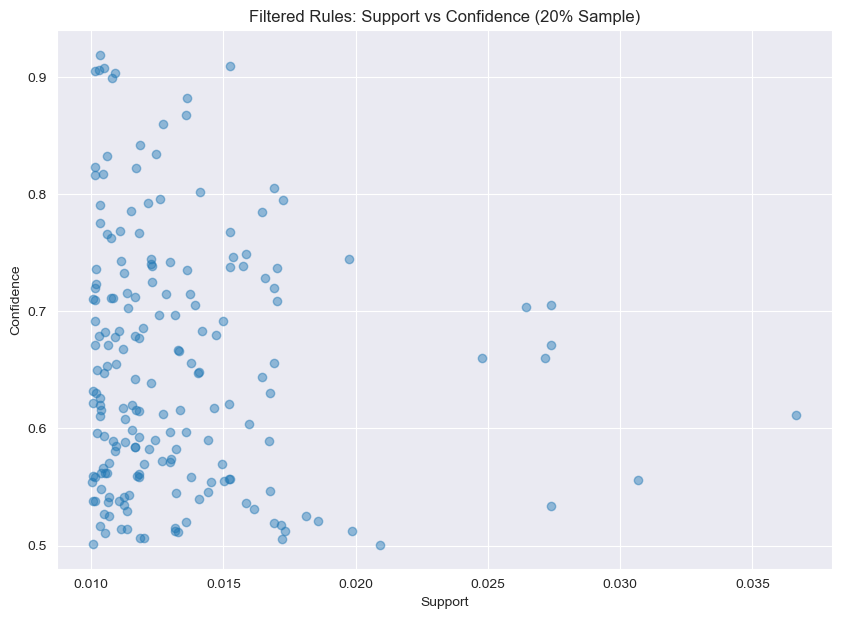

In [73]:
filtered_rules_sample = filtered_rules.sample(
    frac=0.20,
    random_state=42
)

plt.figure(figsize=(10, 7))

plt.scatter(
    filtered_rules_sample["support"],
    filtered_rules_sample["confidence"],
    alpha=0.45
)

plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Filtered Rules: Support vs Confidence (20% Sample)")
plt.grid(True)

plt.show()


# 28. FP-Growth Frequent Itemset Mining

FP-Growth is an alternative frequent itemset mining algorithm.

Instead of repeatedly generating candidate itemsets like Apriori, FP-Growth represents the transaction database using an FP-tree structure and mines frequent patterns from the compressed representation.

The same transaction × product matrix and minimum support used for the Apriori experiment will be used so that the two algorithms can be compared fairly.

In [74]:
from mlxtend.frequent_patterns import fpgrowth
import time

In [75]:
# min_support_fp = 0.01
#
# start_time = time.time()
#
# frequent_itemsets_fp = fpgrowth(
#     basket_matrix,
#     min_support=min_support_fp,
#     use_colnames=True
# )
#
# end_time = time.time()
#
# fp_growth_time = end_time - start_time
#
# print("Minimum support:", min_support_fp)
# print("Frequent itemsets:", len(frequent_itemsets_fp))
# print("Execution time:", round(fp_growth_time, 2), "seconds")

In [76]:
# print("Shape:", frequent_itemsets_fp.shape)
# # print("Number of frequent itemsets:", len(frequent_itemsets_fp))
# frequent_itemsets_fp.head(20)

In [77]:
# import pickle
#
# with open(
#         "../results/frequent_itemsets/frequent_itemsets_fp.pkl",
#         "wb"
# ) as f:
#     pickle.dump(frequent_itemsets_fp, f)


In [78]:
import pickle

with open("../results/frequent_itemsets/frequent_itemsets_fp.pkl", "rb") as f:
    frequent_itemsets_fp = pickle.load(f)

print("Loaded successfully.")

Loaded successfully.


### Check Itemset Sizes

In [79]:
fp_itemset_sizes = (
    frequent_itemsets_fp["itemsets"]
    .apply(len)
)

print(
    fp_itemset_sizes
    .value_counts()
    .sort_index()
)

itemsets
1    829
2    894
3    258
4     25
5      1
Name: count, dtype: int64


### Largest FP-Growth Itemsets

In [80]:
fp_largest_itemsets = frequent_itemsets_fp[
    frequent_itemsets_fp["itemsets"].apply(len) >= 3
    ].copy()

fp_largest_itemsets["itemset_size"] = (
    fp_largest_itemsets["itemsets"].apply(len)
)

fp_largest_itemsets.sort_values(
    ["itemset_size", "support"],
    ascending=[False, False]
).head(20)

,support,itemsets,itemset_size
1021,0.010330,"(20719, 20724, 22356, 22355, 20723)",5
1750,0.015242,"(22698, 22699, 22423, 22697)",4
1060,0.013571,"(21931, 22411, 85099B, 22386)",4
1026,0.013166,"(20719, 20724, 22355, 20723)",4
1667,0.012710,"(20719, 20724, 22356, 22355)",4
1018,0.012406,"(22356, 20724, 22355, 20723)",4
1019,0.012254,"(20719, 20724, 22356, 20723)",4
1484,0.011849,"(21931, 22386, 85099B, 20712)",4
1298,0.011647,"(20727, 22383, 20728, 20725)",4
1219,0.011394,"(22384, 20728, 20727, 20725)",4


# 29. Apriori vs FP-Growth Comparison

| Metric            |    Apriori | FP-Growth |
| ----------------- |-----------:|----------:|
| Minimum support   |       0.01 |      0.01 |
| Frequent itemsets |      2,007 |     2,007 |
| Execution time    | 154.69 sec |  4.67 sec |
| 1-itemsets        |        815 |       815 |
| 2-itemsets        |        917 |       917 |
| 3-itemsets        |        269 |       269 |
| 4-itemsets        |         24 |        24 |
| 5-itemsets        |          1 |         1 |


### Verifying that the actual itemsets are identical

In [81]:
apriori_itemsets = set(
    frequent_itemsets_01["itemsets"]
)

fp_itemsets = set(
    frequent_itemsets_fp["itemsets"]
)

print("Apriori itemsets:", len(apriori_itemsets))
print("FP-Growth itemsets:", len(fp_itemsets))

print(
    "Itemsets found by both:",
    len(apriori_itemsets & fp_itemsets)
)

print(
    "Only in Apriori:",
    len(apriori_itemsets - fp_itemsets)
)

print(
    "Only in FP-Growth:",
    len(fp_itemsets - apriori_itemsets)
)

Apriori itemsets: 2007
FP-Growth itemsets: 2007
Itemsets found by both: 2007
Only in Apriori: 0
Only in FP-Growth: 0


# 29. Experimental Findings

Apriori and FP-Growth were applied to the same transaction × product matrix using a minimum support of 0.01.

Both algorithms generated exactly 2,026 frequent itemsets. Set comparison confirmed that all 2,026 itemsets were common to both algorithms, with no itemsets found exclusively by either algorithm.

The main difference was execution time. Apriori required 154.69 seconds, whereas FP-Growth required 4.67 seconds. Under the conditions of this experiment, FP-Growth completed the mining process approximately 33.1 times faster than Apriori.

The results demonstrate that both algorithms produced the same frequent-pattern results for the selected support threshold, while their computational performance differed substantially.

# 30. FP-Growth Itemset Size Distribution

The frequent itemsets generated by FP-Growth are examined according to the number of products contained in each itemset.

This helps identify whether the discovered patterns are primarily individual products, product pairs, or larger combinations.

In [82]:
fp_itemset_sizes = (
    frequent_itemsets_fp["itemsets"]
    .apply(len)
)

fp_itemset_size_counts = (
    fp_itemset_sizes
    .value_counts()
    .sort_index()
)

fp_itemset_size_counts

itemsets
1    829
2    894
3    258
4     25
5      1
Name: count, dtype: int64

### Inspecting frequent itemsets by support

In [83]:
fp_top_itemsets = frequent_itemsets_fp.sort_values(
    "support",
    ascending=False
)

fp_top_itemsets.head(20)

,support,itemsets
0,0.111302,(85123A)
97,0.105783,(85099B)
313,0.100668,(22423)
614,0.085325,(47566)
43,0.079249,(20725)
8,0.073678,(84879)
110,0.070488,(22197)
646,0.070134,(22720)
44,0.066842,(21212)
179,0.065019,(22383)


# 31 Association Rule Generation from FP-Growth

Association rules are generated from the frequent itemsets obtained using FP-Growth.

The same confidence threshold used for the Apriori rule generation is applied so that the two rule sets can be compared fairly.

In [84]:
from mlxtend.frequent_patterns import association_rules

rules_fp = association_rules(
    frequent_itemsets_fp,
    metric="confidence",
    min_threshold=0.1
)

print("Number of FP-Growth rules:", len(rules_fp))

Number of FP-Growth rules: 3670


In [85]:
with open(
        "../results/association_rules/rules_fp.pkl",
        "wb"
) as f:
    pickle.dump(rules_fp, f)

print("FP-Growth rules saved.")

FP-Growth rules saved.


In [86]:
rules_fp[
    ["antecedents", "consequents", "support", "confidence", "lift"]
].head(20)

,antecedents,consequents,support,confidence,lift
0,(22865),(22633),0.011951,0.360856,14.877223
1,(22633),(22865),0.011951,0.492693,14.877223
2,(22866),(22633),0.010887,0.392336,16.175045
3,(22633),(22866),0.010887,0.448852,16.175045
4,(22632),(22865),0.010583,0.533163,16.099248
5,(22865),(22632),0.010583,0.319572,16.099248
6,(22632),(22866),0.010330,0.520408,18.753687
7,(22866),(22632),0.010330,0.372263,18.753687
8,(85123A),(84879),0.016407,0.147407,2.000679
9,(84879),(85123A),0.016407,0.222680,2.000679


In [87]:
print("Apriori rules:", len(rules_01))
print("FP-Growth rules:", len(rules_fp))

Apriori rules: 3670
FP-Growth rules: 3670


### Verifying the Actual Rules

In [88]:
apriori_rules_set = set(
    zip(
        rules_01["antecedents"],
        rules_01["consequents"]
    )
)

fp_rules_set = set(
    zip(
        rules_fp["antecedents"],
        rules_fp["consequents"]
    )
)

print("Apriori rules:", len(apriori_rules_set))
print("FP-Growth rules:", len(fp_rules_set))

print(
    "Rules found by both:",
    len(apriori_rules_set & fp_rules_set)
)

print(
    "Only in Apriori:",
    len(apriori_rules_set - fp_rules_set)
)

print(
    "Only in FP-Growth:",
    len(fp_rules_set - apriori_rules_set)
)


Apriori rules: 3670
FP-Growth rules: 3670
Rules found by both: 3670
Only in Apriori: 0
Only in FP-Growth: 0


# 31. StockCode → Product Description Mapping

### Mapping

In [89]:
product_description_map = (
    df_clean[["StockCode" , "Description"]]
    .dropna(subset=["Description"])
    .drop_duplicates("StockCode")
    .set_index("StockCode")["Description"]
    .to_dict()
)
print("Number of mapped products:", len(product_description_map))

Number of mapped products: 3917


In [90]:
for stock_code in ["85123A", "85099B", "22386"]:
    print(
        stock_code,
        "→",
        product_description_map.get(stock_code)
    )

85123A → WHITE HANGING HEART T-LIGHT HOLDER
85099B → JUMBO BAG RED RETROSPOT
22386 → JUMBO BAG PINK POLKADOT


### Convert the rules to readable descriptions

In [91]:
import pickle

with open(
        "../results/association_rules/rules_fp.pkl",
        "rb"
) as f:
    rules_fp = pickle.load(f)


In [92]:
readable_rules = rules_fp.copy()

def convert_itemset(itemset):
    return ", ".join(
        product_description_map.get(item, str(item))
        for item in itemset
    )

readable_rules["antecedents_description"] = (
    readable_rules["antecedents"]
    .apply(convert_itemset)
)

readable_rules["consequents_description"] = (
    readable_rules["consequents"]
    .apply(convert_itemset)
)

In [93]:
readable_rules["rule"] = (
        readable_rules["antecedents_description"].astype(str)
        + " → "
        + readable_rules["consequents_description"].astype(str)
)

In [94]:
readable_rules[
    [
        "rule",
        "support",
        "confidence",
        "lift"
    ]
].sort_values("confidence" , ascending=False).head(200)

,rule,support,confidence,lift
1877,"HERB MARKER THYME, HERB MARKER PARSLEY → HERB ...",0.010280,0.953052,78.420266
1883,"HERB MARKER THYME, HERB MARKER BASIL → HERB MA...",0.010128,0.952381,78.365079
3592,"REGENCY TEA PLATE ROSES , REGENCY TEA PLATE PI...",0.012913,0.947955,49.134444
1879,"HERB MARKER PARSLEY, HERB MARKER ROSEMARY → HE...",0.010280,0.944186,78.674203
1884,"HERB MARKER BASIL, HERB MARKER ROSEMARY → HERB...",0.010128,0.934579,77.873733
...,...,...,...,...
206,"JUMBO BAG DOILEY PATTERNS, JUMBO BAG PINK POLK...",0.012102,0.744548,7.038458
2431,"JUMBO BAG TOYS , JUMBO SHOPPER VINTAGE RED PAI...",0.010026,0.744361,17.033186
2536,"WOODLAND CHARLOTTE BAG, LUNCH BAG RED RETROSPO...",0.011647,0.744337,14.243371
706,"JUMBO STORAGE BAG SUKI, JUMBO SHOPPER VINTAGE ...",0.019749,0.744275,7.035873


In [95]:
# import pickle
#
# with open(
#         "../results/association_rules/readable_rules.pkl",
#         "wb"
# ) as f:
#     pickle.dump(readable_rules, f)


## Business Interpretation

In [96]:
readable_rules[
    ["rule", "support", "confidence", "lift"]
].sort_values(
    "lift",
    ascending=False
).head(20)

,rule,support,confidence,lift
1880,"HERB MARKER THYME → HERB MARKER PARSLEY, HERB ...",0.010280,0.856540,78.674203
1879,"HERB MARKER PARSLEY, HERB MARKER ROSEMARY → HE...",0.010280,0.944186,78.674203
1877,"HERB MARKER THYME, HERB MARKER PARSLEY → HERB ...",0.010280,0.953052,78.420266
1882,"HERB MARKER ROSEMARY → HERB MARKER THYME, HERB...",0.010280,0.845833,78.420266
1888,"HERB MARKER ROSEMARY → HERB MARKER THYME, HERB...",0.010128,0.833333,78.365079
1883,"HERB MARKER THYME, HERB MARKER BASIL → HERB MA...",0.010128,0.952381,78.365079
1887,"HERB MARKER THYME → HERB MARKER BASIL, HERB MA...",0.010128,0.843882,77.873733
1884,"HERB MARKER BASIL, HERB MARKER ROSEMARY → HERB...",0.010128,0.934579,77.873733
1869,HERB MARKER THYME → HERB MARKER ROSEMARY,0.011191,0.932489,76.728340
1870,HERB MARKER ROSEMARY → HERB MARKER THYME,0.011191,0.920833,76.728340



The discovered association rules reveal groups of products that frequently occur together within customer transactions.

These associations can provide useful information for product bundling, cross-selling, recommendation systems, promotional planning, and inventory planning.

For example, strong associations among different designs of the same product category suggest that customers may purchase multiple related variants together. Similarly, associations among complementary products can indicate potential opportunities for bundle recommendations.

Support indicates how frequently an association occurs across transactions, confidence indicates how often the consequent appears when the antecedent is present, and lift indicates how much more frequently the consequent occurs compared with its overall occurrence.

The rules represent associations in the transaction data and should not be interpreted as evidence that purchasing one product causes the purchase of another.

## Final Conclusion

This project applied Association Rule Learning to the UCI Online Retail dataset to discover products that tend to occur together in customer transactions.

The raw transaction data was cleaned by removing cancelled transactions, negative quantities, invalid prices, and non-product/service entries. The cleaned transaction data was then converted into an invoice-level binary basket representation, where each product indicates whether it was present in a transaction.

Product frequency analysis was used to identify commonly occurring products, and a minimum product-occurrence threshold was applied before constructing the transaction × product matrix.

Apriori and FP-Growth were then used to discover frequent itemsets. At a minimum support of 0.01, both methods produced the same frequent-itemset results. Apriori generated 2,026 frequent itemsets in approximately 154.69 seconds, while FP-Growth generated the same number in approximately 4.67 seconds in this experiment.

Association rules were generated using support, confidence, and lift. Converting StockCodes into product descriptions made the discovered relationships easier to interpret. The resulting rules revealed associations among related product categories and product variants, which can potentially support cross-selling, product recommendations, and bundle planning.

The analysis also demonstrated that association-rule mining is sensitive to preprocessing and parameter choices. Non-product/service entries can produce rules that are difficult to interpret from a product-association perspective, while lower support thresholds can substantially increase computational requirements.

Overall, the project demonstrates the complete association-rule-mining workflow: data cleaning, basket construction, frequent-itemset mining, rule generation, metric interpretation, algorithm comparison, and business interpretation.

In [103]:
import pickle

# Load Apriori results
with open("../results/frequent_itemsets/apriori_results.pkl", "rb") as f:
    apriori_results = pickle.load(f)

# Load FP-Growth results
with open("../results/frequent_itemsets/frequent_itemsets_fp.pkl", "rb") as f:
    frequent_itemsets_fp = pickle.load(f)

# Select Apriori result for support = 0.01
frequent_itemsets_apriori = apriori_results[0.01]

print("========== COMPARISON ==========")

print("\nFrequent Itemsets")
print("-----------------")
print("Apriori:", len(frequent_itemsets_apriori))
print("FP-Growth:", len(frequent_itemsets_fp))

# Convert itemsets to comparable sets
apriori_sets = set(
    frequent_itemsets_apriori["itemsets"].apply(frozenset)
)

fp_sets = set(
    frequent_itemsets_fp["itemsets"].apply(frozenset)
)

print("\nItemset Comparison")
print("------------------")
print("Common:", len(apriori_sets & fp_sets))
print("Only Apriori:", len(apriori_sets - fp_sets))
print("Only FP-Growth:", len(fp_sets - apriori_sets))
print("Exact Match:", apriori_sets == fp_sets)

========== COMPARISON ==========

Frequent Itemsets
-----------------
Apriori: 2007
FP-Growth: 2007

Itemset Comparison
------------------
Common: 2007
Only Apriori: 0
Only FP-Growth: 0
Exact Match: True


| Aspect                          | Apriori                                  | FP-Growth                           |
| ------------------------------- | ---------------------------------------- | ----------------------------------- |
| **Approach**                    | Candidate generation + pruning           | FP-Tree + pattern growth            |
| **Candidate generation**        | Yes                                      | No explicit candidate generation    |
| **Database scans**              | Multiple scans                           | Fewer scans                         |
| **Memory usage**                | Can increase due to candidate generation | Generally more efficient            |
| **Scalability**                 | Can become expensive at low support      | Generally better for large datasets |
| **Minimum support**             | 0.01                                     | 0.01                                |
| **Frequent itemsets generated** | **2,007**                                | **2,007**                           |
| **Common itemsets**             | **2,007**                                | **2,007**                           |
| **Only found by algorithm**     | 0                                        | 0                                   |
| **Exact itemset match**         | **Yes**                                  | **Yes**                             |
| **Rules generated**             | To be filled from product-only run       | To be filled from product-only run  |
| **Execution time**              | To be filled                             | To be filled                        |
